# Multi-Armed Bandits

## The k-Armed Bandit Problem

Imagine $k$ slot machines ("one-armed bandits"). Each machine has an unknown reward distribution. You want to **maximize total reward** over $T$ pulls.

This is the **simplest RL problem** no states, just actions. It isolates the exploration-exploitation trade-off.

**Formal definition**:
- $k$ actions (arms)
- True value of action $a$: $q_*(a) = \mathbb{E}[R_t | A_t = a]$
- Goal: minimize **cumulative regret** $L_T = \sum_{t=1}^T [q_*(a^*) - q_*(A_t)]$

---

## Stationary vs Non-Stationary

- **Stationary**: reward distributions don't change over time
- **Non-stationary**: distributions shift use **exponential recency weighting**:
  $$Q_{n+1}(a) = Q_n(a) + \alpha[R_n - Q_n(a)]$$
  where $\alpha \in (0,1]$ is a constant step size (recent rewards weighted more).

---

## Action-Value Methods

### Sample Average

$$Q_t(a) = \frac{\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}[A_i=a]}{N_t(a)}$$

**Incremental update** (efficient, O(1) per step):

$$Q_{n+1}(a) = Q_n(a) + \frac{1}{n}[R_n - Q_n(a)]$$

---

## ε-Greedy

$$A_t = \begin{cases} \arg\max_a Q_t(a) & \text{with prob } 1-\epsilon \\ \text{random action} & \text{with prob } \epsilon \end{cases}$$

Simple but suboptimal explores uniformly rather than targeting uncertain arms.

---

## UCB (Upper Confidence Bound)

**Optimism in the face of uncertainty** choose action with highest upper confidence bound:

$$A_t = \arg\max_a \left[Q_t(a) + c\sqrt{\frac{\ln t}{N_t(a)}}\right]$$

- $Q_t(a)$: exploitation term (estimated value)
- $c\sqrt{\frac{\ln t}{N_t(a)}}$: exploration bonus (decreases as arm is pulled more)
- $c$ controls exploration-exploitation balance

**UCB1** achieves $O(\sqrt{kT\ln T})$ regret near-optimal for stationary bandits.

---

## Gradient Bandit

Learn **preference** $H_t(a)$ for each action. Policy via softmax:

$$\pi_t(a) = \frac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}}$$

Update preferences using stochastic gradient ascent:

$$H_{t+1}(A_t) = H_t(A_t) + \alpha(R_t - \bar{R}_t)(1 - \pi_t(A_t))$$

$$H_{t+1}(a) = H_t(a) - \alpha(R_t - \bar{R}_t)\pi_t(a), \quad \forall a \neq A_t$$

where $\bar{R}_t$ is a baseline (running average reward).

---

## Thompson Sampling (Bayesian Approach)

Maintain posterior distribution over $q_*(a)$. Sample from posterior, choose arm with highest sample.

**Beta-Bernoulli Bandit** (binary rewards $r \in \{0,1\}$):
- Prior: $Q_*(a) \sim \text{Beta}(\alpha_a, \beta_a)$
- After pulling arm $a$ and observing $r$:
  - $\alpha_a \leftarrow \alpha_a + r$
  - $\beta_a \leftarrow \beta_a + (1-r)$
- At each step: sample $\theta_a \sim \text{Beta}(\alpha_a, \beta_a)$, pull $\arg\max_a \theta_a$

**Regret**: $O(\sqrt{kT\ln k})$ matches information-theoretic lower bound!

---

## Contextual Bandits

Extend bandits with a **context** (feature vector) $x_t$ at each step. Learn $Q(x_t, a)$.

### LinUCB

Assume linear reward: $r = x_t^T \theta_a + \epsilon$

$$A_t = \arg\max_a \left[x_t^T \hat{\theta}_a + \alpha \sqrt{x_t^T A_a^{-1} x_t}\right]$$

where $A_a = I + \sum_{\tau} x_\tau x_\tau^T$ and $\hat{\theta}_a = A_a^{-1} b_a$.

---

## Bayesian Optimization

Use bandits for expensive black-box function optimization (e.g., hyperparameter tuning).

**Framework**:
1. Maintain a **surrogate model** (Gaussian Process) of the objective $f$
2. Use **acquisition function** to decide where to evaluate next

### Acquisition Functions

**Expected Improvement (EI)**:
$$EI(x) = \mathbb{E}[\max(f(x) - f(x^+), 0)] = (\mu(x) - f(x^+))\Phi(Z) + \sigma(x)\phi(Z)$$
where $Z = \frac{\mu(x) - f(x^+)}{\sigma(x)}$

**Upper Confidence Bound (GP-UCB)**:
$$UCB(x) = \mu(x) + \kappa\sigma(x)$$

**Probability of Improvement (PI)**:
$$PI(x) = \Phi\left(\frac{\mu(x) - f(x^+)}{\sigma(x)}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)

# ─── k-Armed Bandit Simulation ───
class BernoulliBandit:
    def __init__(self, k=10, seed=42):
        np.random.seed(seed)
        self.k = k
        self.true_probs = np.random.uniform(0.1, 0.9, k)
        self.best = np.argmax(self.true_probs)

    def pull(self, arm):
        return 1 if np.random.rand() < self.true_probs[arm] else 0

bandit = BernoulliBandit(k=10)
print(f"True arm probabilities: {bandit.true_probs.round(3)}")
print(f"Best arm: {bandit.best} with p={bandit.true_probs[bandit.best]:.3f}")

True arm probabilities: [0.4   0.861 0.686 0.579 0.225 0.225 0.146 0.793 0.581 0.666]
Best arm: 1 with p=0.861


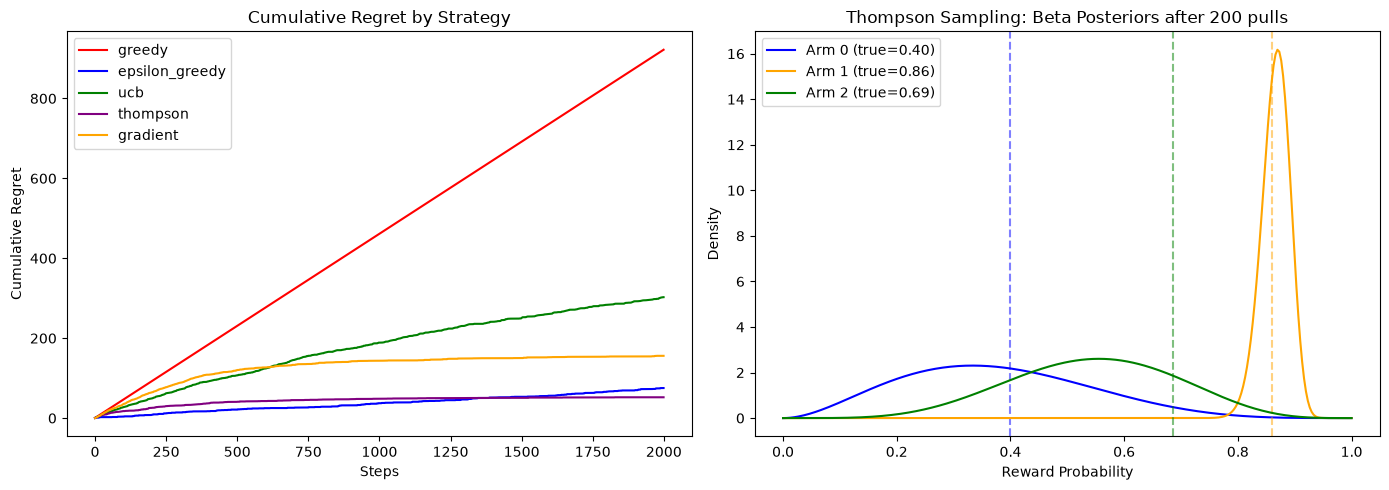

In [2]:
# ─── Compare Strategies ───
def run_strategy(strategy, bandit, T=1000):
    k = bandit.k
    Q = np.zeros(k)
    N = np.zeros(k, dtype=int)
    # Thompson sampling state
    alpha_ts = np.ones(k); beta_ts = np.ones(k)
    H = np.zeros(k)  # gradient bandit preferences

    rewards, regrets = [], []
    R_bar = 0  # running average for gradient bandit

    for t in range(1, T+1):
        if strategy == 'epsilon_greedy':
            a = np.random.randint(k) if np.random.rand() < 0.1 else np.argmax(Q)
        elif strategy == 'ucb':
            if np.any(N == 0):
                a = np.where(N == 0)[0][0]
            else:
                a = np.argmax(Q + 2.0 * np.sqrt(np.log(t) / N))
        elif strategy == 'thompson':
            samples = np.array([beta_dist.rvs(alpha_ts[i], beta_ts[i]) for i in range(k)])
            a = np.argmax(samples)
        elif strategy == 'gradient':
            probs = np.exp(H) / np.sum(np.exp(H))
            a = np.random.choice(k, p=probs)
        elif strategy == 'greedy':
            a = np.argmax(Q)

        r = bandit.pull(a)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]

        if strategy == 'thompson':
            if r == 1: alpha_ts[a] += 1
            else:      beta_ts[a]  += 1

        if strategy == 'gradient':
            R_bar += (r - R_bar) / t
            probs = np.exp(H) / np.sum(np.exp(H))
            H[a]  += 0.1 * (r - R_bar) * (1 - probs[a])
            for b in range(k):
                if b != a: H[b] -= 0.1 * (r - R_bar) * probs[b]

        rewards.append(r)
        regrets.append(bandit.true_probs[bandit.best] - bandit.true_probs[a])

    return rewards, np.cumsum(regrets)


T = 2000
strategies = ['greedy','epsilon_greedy','ucb','thompson','gradient']
colors     = ['red','blue','green','purple','orange']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strat, col in zip(strategies, colors):
    _, cum_regret = run_strategy(strat, bandit, T)
    axes[0].plot(cum_regret, label=strat, color=col)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Cumulative Regret')
axes[0].set_title('Cumulative Regret by Strategy'); axes[0].legend()

# Thompson Sampling posterior visualization
np.random.seed(0)
ts_bandit = BernoulliBandit(k=3)
alphas, betas_ = np.ones(3), np.ones(3)
for _ in range(200):
    samples = [beta_dist.rvs(alphas[i], betas_[i]) for i in range(3)]
    a = np.argmax(samples)
    r = ts_bandit.pull(a)
    if r == 1: alphas[a] += 1
    else:      betas_[a]  += 1

x = np.linspace(0, 1, 300)
colors3 = ['blue','orange','green']
for i in range(3):
    y = beta_dist.pdf(x, alphas[i], betas_[i])
    axes[1].plot(x, y, color=colors3[i],
                 label=f'Arm {i} (true={ts_bandit.true_probs[i]:.2f})')
    axes[1].axvline(ts_bandit.true_probs[i], color=colors3[i], linestyle='--', alpha=0.5)

axes[1].set_xlabel('Reward Probability'); axes[1].set_ylabel('Density')
axes[1].set_title('Thompson Sampling: Beta Posteriors after 200 pulls')
axes[1].legend()

plt.tight_layout(); plt.show()

In [3]:
# ─── Bayesian Optimization with scipy ───
from scipy.stats import norm
from scipy.optimize import minimize

# True objective (unknown to optimizer)
def true_f(x): return -(x**2) * np.sin(5*np.pi*x)**6

# Gaussian Process surrogate (simplified with RBF kernel)
class SimpleGP:
    def __init__(self, noise=1e-6):
        self.X, self.y, self.noise = [], [], noise

    def rbf(self, x1, x2, l=0.3, sigma=1.0):
        return sigma**2 * np.exp(-0.5 * ((x1-x2)/l)**2)

    def fit(self, X, y):
        self.X = np.array(X); self.y = np.array(y)
        n = len(X)
        K = np.array([[self.rbf(self.X[i], self.X[j]) for j in range(n)] for i in range(n)])
        K += self.noise * np.eye(n)
        self.K_inv = np.linalg.inv(K)

    def predict(self, x_new):
        k_star = np.array([self.rbf(xi, x_new) for xi in self.X])
        mu  = k_star @ self.K_inv @ self.y
        var = self.rbf(x_new, x_new) - k_star @ self.K_inv @ k_star
        return mu, max(var, 1e-8)**0.5

def expected_improvement(x, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(x)
    Z = (mu - y_best - xi) / sigma
    return (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)

# BO loop
gp = SimpleGP()
X_obs = list(np.random.uniform(0,1,3))
y_obs = [true_f(x) for x in X_obs]

for i in range(10):
    gp.fit(X_obs, y_obs)
    x_cands = np.linspace(0, 1, 200)
    y_best  = max(y_obs)
    ei_vals = [expected_improvement(x, gp, y_best) for x in x_cands]
    x_next  = x_cands[np.argmax(ei_vals)]
    X_obs.append(x_next); y_obs.append(true_f(x_next))

best_x = X_obs[np.argmax(y_obs)]
print(f"Bayesian Optimization found: x={best_x:.4f}, f(x)={true_f(best_x):.4f}")
print(f"True maximum near x=0.9 (f≈{true_f(0.9):.4f})")

Bayesian Optimization found: x=0.0000, f(x)=-0.0000
True maximum near x=0.9 (f≈-0.8100)


## Additional Learning Resources

### Books
- **Sutton & Barto Ch. 2** Multi-armed Bandits: http://incompleteideas.net/book/the-book-2nd.html
- **Bandit Algorithms** Tor Lattimore (free): https://tor-lattimore.com/downloads/book/book.pdf

### Papers
- **UCB1** Auer et al. 2002: https://link.springer.com/article/10.1023/A:1013689704352
- **Thompson Sampling** Chapelle & Li 2011: https://papers.nips.cc/paper/4321-an-empirical-evaluation-of-thompson-sampling
- **LinUCB** Li et al. 2010: https://arxiv.org/abs/1003.0146
- **Bayesian Optimization** survey: https://arxiv.org/abs/1807.02811

### Libraries
- **Ax** (Bayesian Optimization, Meta): https://ax.dev/
- **Optuna** (hyperparameter search): https://optuna.org/
- **BoTorch** (Bayesian Optimization in PyTorch): https://botorch.org/
- **Vowpal Wabbit** (contextual bandits): https://vowpalwabbit.org/

### Applications
- **A/B Testing** as bandit: https://conductricsblog.wordpress.com/
- **RecSys** with bandits: https://dl.acm.org/doi/10.1145/1553374.1553421